# Notebook 4: Asset-Liability Management (ALM)

This notebook reads outputs from the R notebooks (mortality tables, Lee-Carter projection,
BD plan valuation) and performs the ALM analysis in Python.

**Run R notebooks first:** 01 → 02 → 03 (they generate the CSVs in `data/processed/`)

Topics:
- Project benefit cash flows and calculate liability duration
- NTN-B bond pricing and duration
- Duration gap analysis
- Parallel shift interest rate stress test
- Portfolio immunization suggestion

In [1]:
import sys
sys.path.append('../src/python')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from alm import (
    load_r_outputs, project_liability_cash_flows,
    macaulay_duration, modified_duration, convexity, present_value,
    NTNBBond, portfolio_duration, ALMAnalysis
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load R Outputs

In [2]:
data = load_r_outputs('../data/processed')

participants  = data['participants']
summary_stats = data['summary']
e_hist        = data['e_hist']
e_proj        = data['e_proj']
long_sens     = data['long_sens']

print(f'Participants loaded: {len(participants):,}')
print(f'Active:  {(participants["status"]=="active").sum():,}')
print(f'Retired: {(participants["status"]=="retired").sum():,}')

if summary_stats is not None:
    s = summary_stats.set_index('metric')['value']
    discount_rate = float(s.get('discount_rate', 0.0575))
    total_liab    = float(s.get('total_liability', 0))
    print(f'\nDiscount rate from R:    {discount_rate:.2%}')
    print(f'Total liability from R:  R$ {total_liab/1e6:.1f}M')
else:
    discount_rate = 0.0575
    print('Summary stats not found — using default discount rate 5.75%')

Participants loaded: 700
Active:  500
Retired: 200

Discount rate from R:    5.75%
Total liability from R:  R$ 370.5M


## 2. Life Expectancy from Lee-Carter (R output)

Showing the projection produced by `StMoMo` in notebook 02.

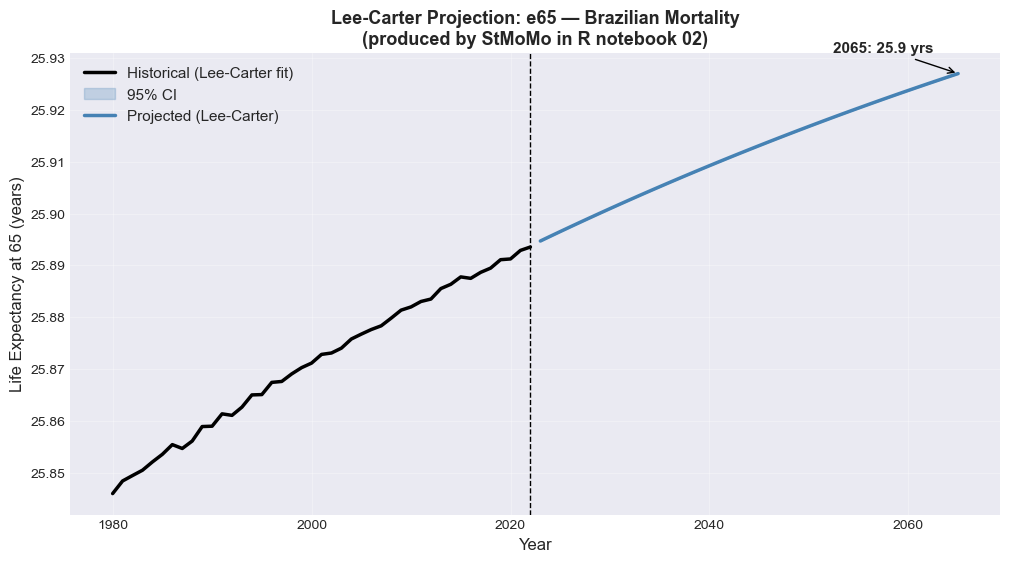

Final e65 (2065): 25.9 yrs


In [3]:
if e_hist is not None and e_proj is not None:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(e_hist['year'], e_hist['e65'], color='black',
            linewidth=2.5, label='Historical (Lee-Carter fit)')
    ax.fill_between(e_proj['year'], e_proj['e65_low'], e_proj['e65_high'],
                    alpha=0.25, color='steelblue', label='95% CI')
    ax.plot(e_proj['year'], e_proj['e65_mean'], color='steelblue',
            linewidth=2.5, label='Projected (Lee-Carter)')
    ax.axvline(x=2022, color='black', linestyle='--', linewidth=1)

    last = e_proj.iloc[-1]
    ax.annotate(f"2065: {last['e65_mean']:.1f} yrs",
                xy=(last['year'], last['e65_mean']),
                xytext=(-90, 15), textcoords='offset points',
                fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='->'))

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Life Expectancy at 65 (years)', fontsize=12)
    ax.set_title('Lee-Carter Projection: e65 — Brazilian Mortality\n'
                 '(produced by StMoMo in R notebook 02)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.savefig('../results/figures/09_e65_from_R.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Final e65 (2065): {last["e65_mean"]:.1f} yrs')
else:
    print('Lee-Carter data not found. Run R notebook 02 first.')

## 3. Project Liability Cash Flows

In [4]:
years_cf, cash_flows = project_liability_cash_flows(
    participants, discount_rate=discount_rate,
    retirement_age=65, n_years=50
)

liab_pv    = present_value(cash_flows, discount_rate)
liab_D_mac = macaulay_duration(cash_flows, discount_rate)
liab_D_mod = modified_duration(cash_flows, discount_rate)

print(f'Liability Cash Flows:')
print(f'  Present Value:      R$ {liab_pv/1e6:,.1f}M')
print(f'  Macaulay Duration:  {liab_D_mac:.2f} years')
print(f'  Modified Duration:  {liab_D_mod:.2f}')
print(f'  Interpretation: 1% rate rise → liability falls ~{liab_D_mod:.1f}%')

Liability Cash Flows:
  Present Value:      R$ 494.8M
  Macaulay Duration:  18.52 years
  Modified Duration:  17.51
  Interpretation: 1% rate rise → liability falls ~17.5%


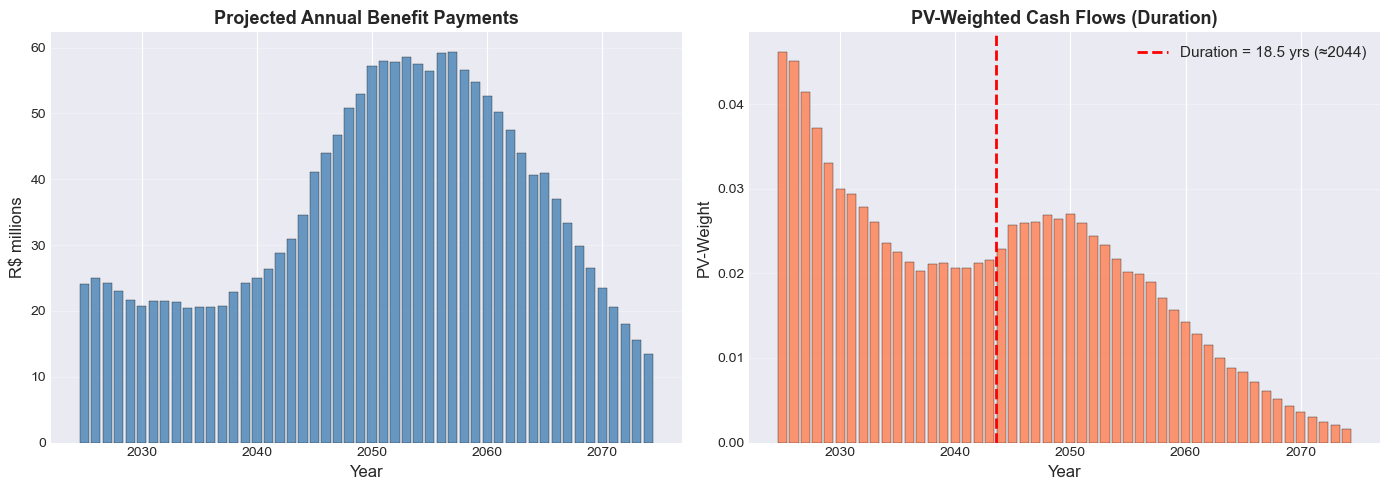

In [5]:
proj_years_cf = 2025 + years_cf
v = 1 / (1 + discount_rate)
pv_weights = cash_flows * v**(years_cf+1)
pv_weights = pv_weights / pv_weights.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(proj_years_cf, cash_flows/1e6, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('R$ millions', fontsize=12)
axes[0].set_title('Projected Annual Benefit Payments', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(proj_years_cf, pv_weights, color='coral', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].axvline(x=2025+liab_D_mac, color='red', linestyle='--', linewidth=2,
                label=f'Duration = {liab_D_mac:.1f} yrs (≈{2025+liab_D_mac:.0f})')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('PV-Weight', fontsize=12)
axes[1].set_title('PV-Weighted Cash Flows (Duration)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/10_liability_cash_flows.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. NTN-B Portfolio Analysis

In [7]:
bonds = [
    (NTNBBond(2030, real_yield=0.063), 0.20),
    (NTNBBond(2035, real_yield=0.062), 0.25),
    (NTNBBond(2040, real_yield=0.062), 0.20),
    (NTNBBond(2045, real_yield=0.061), 0.20),
    (NTNBBond(2050, real_yield=0.061), 0.15),
]

print('NTN-B Portfolio:')
print(f'{"Bond":<15} {"Weight":>8} {"Duration":>10} {"Price":>10}')
for bond, w in bonds:
    print(f'  NTN-B {bond.maturity_year}  {w:>7.0%}  {bond.macaulay_duration():>9.2f}  {bond.price_per_unit():>9.2f}')

port_dur = portfolio_duration(bonds)
print(f'\nPortfolio Macaulay Duration: {port_dur:.2f} years')

NTN-B Portfolio:
Bond              Weight   Duration      Price
  NTN-B 2030      20%       4.46     987.47
  NTN-B 2035      25%       7.78     985.42
  NTN-B 2040      20%      10.25     980.83
  NTN-B 2045      20%      12.11     988.62
  NTN-B 2050      15%      13.48     987.34

Portfolio Macaulay Duration: 9.33 years


## 5. Duration Gap and Immunization

In [8]:
alm = ALMAnalysis(cash_flows, discount_rate, bonds)
alm.summary()

imm = alm.immunization_suggestion()
print('\nImmunization Suggestion:')
for k, v in imm.items():
    print(f'  {k:<25} {round(v,4) if isinstance(v,float) else v}')

ALM SUMMARY

LIABILITIES
  Present Value:      R$      494.8M
  Macaulay Duration:       18.52 years
  Modified Duration:       17.51

ASSETS (NTN-B Portfolio, FR=100%)
  Value:              R$      494.8M
  Macaulay Duration:        9.33 years

SURPLUS
  Surplus:            R$        0.0M
  Funding Ratio:          100.0%

DURATION GAP:               9.19 years
  Assessment: Liabilities longer → exposed to rate DROPS

Immunization Suggestion:
  note                      Target (18.5 yrs) exceeds longest available bond (14.6 yrs). Consider NTN-B 2055 + interest rate swaps.
  target_duration           18.5196
  suggested_bond            NTN-B 2055
  bond_duration             14.5907
  residual_gap              3.9289


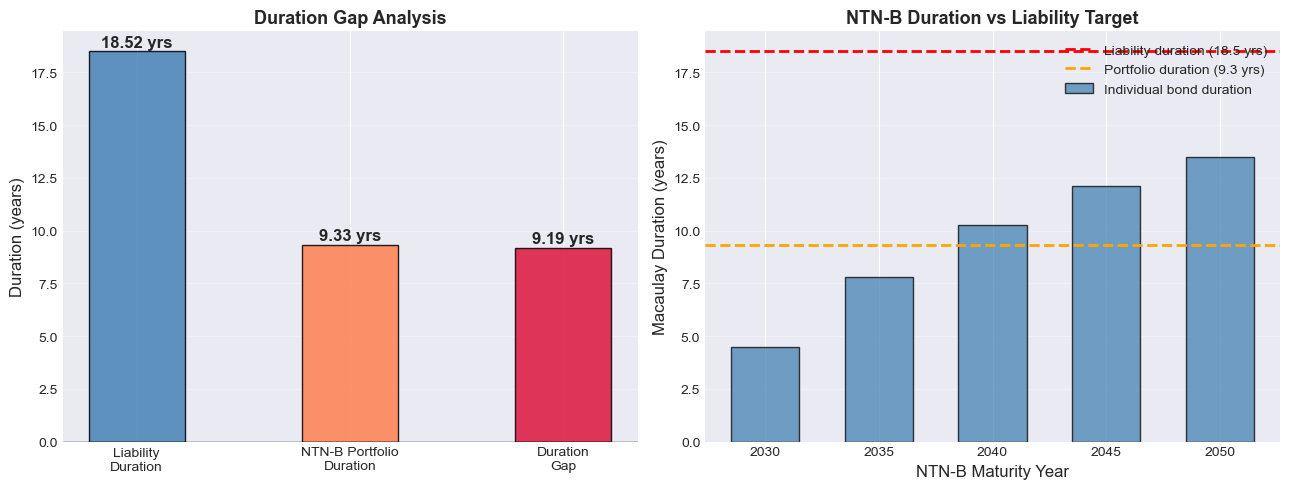

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

items  = ['Liability\nDuration', 'NTN-B Portfolio\nDuration', 'Duration\nGap']
vals   = [alm.liab_D_mac, alm.asset_D_mac, alm.duration_gap]
clrs   = ['steelblue', 'coral', 'crimson' if alm.duration_gap > 1 else 'seagreen']

bars = axes[0].bar(items, vals, color=clrs, alpha=0.85, edgecolor='black', width=0.45)
axes[0].axhline(0, color='black', linewidth=1)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+(0.2 if v>=0 else -0.7),
                 f'{v:.2f} yrs', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Duration (years)', fontsize=12)
axes[0].set_title('Duration Gap Analysis', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

mat_years = [b.maturity_year for b, _ in bonds]
durs      = [b.macaulay_duration() for b, _ in bonds]
weights   = [w for _, w in bonds]

axes[1].bar(mat_years, durs, width=3, alpha=0.75, color='steelblue', edgecolor='black',
            label='Individual bond duration')
axes[1].axhline(alm.liab_D_mac,  color='red',    linestyle='--', linewidth=2,
                label=f'Liability duration ({alm.liab_D_mac:.1f} yrs)')
axes[1].axhline(alm.asset_D_mac, color='orange', linestyle='--', linewidth=2,
                label=f'Portfolio duration ({alm.asset_D_mac:.1f} yrs)')
axes[1].set_xlabel('NTN-B Maturity Year', fontsize=12)
axes[1].set_ylabel('Macaulay Duration (years)', fontsize=12)
axes[1].set_title('NTN-B Duration vs Liability Target', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/11_duration_gap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Interest Rate Stress Test

In [10]:
stress = alm.interest_rate_stress(shocks_bp=(-200,-100,-50,50,100,200))
print('Interest Rate Stress Test:')
print(stress.round(0).to_string(index=False))
stress.to_csv('../results/tables/interest_rate_stress.csv', index=False)

Interest Rate Stress Test:
 shock_bp  new_liability   new_asset      surplus  surplus_pct
     -200    713634792.0 593989057.0 -119645734.0        -17.0
     -100    592822141.0 541415810.0  -51406330.0         -9.0
      -50    540956495.0 517357464.0  -23599031.0         -4.0
       50    454306563.0 473697326.0   19390763.0          4.0
      100    419522277.0 454095534.0   34573257.0          8.0
      200    367035064.0 419348504.0   52313440.0         14.0


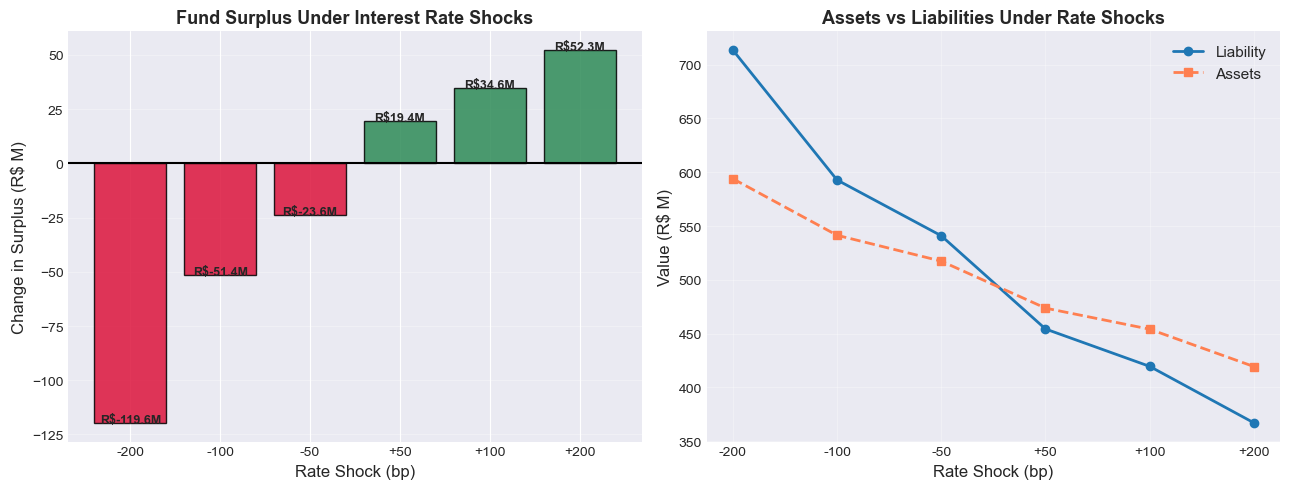

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clrs_s = ['seagreen' if v >= 0 else 'crimson' for v in stress['surplus']]
axes[0].bar([f'{s:+d}' for s in stress['shock_bp']], stress['surplus']/1e6,
            color=clrs_s, alpha=0.85, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=1.5)
for i, (bp, val) in enumerate(zip(stress['shock_bp'], stress['surplus'])):
    axes[0].text(i, val/1e6+(0.02 if val>=0 else -0.08),
                 f'R${val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Rate Shock (bp)', fontsize=12)
axes[0].set_ylabel('Change in Surplus (R$ M)', fontsize=12)
axes[0].set_title('Fund Surplus Under Interest Rate Shocks', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot([f'{s:+d}' for s in stress['shock_bp']],
             stress['new_liability']/1e6, 'o-', linewidth=2, label='Liability')
axes[1].plot([f'{s:+d}' for s in stress['shock_bp']],
             stress['new_asset']/1e6, 's--', linewidth=2, color='coral', label='Assets')
axes[1].set_xlabel('Rate Shock (bp)', fontsize=12)
axes[1].set_ylabel('Value (R$ M)', fontsize=12)
axes[1].set_title('Assets vs Liabilities Under Rate Shocks', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/12_interest_rate_stress.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Longevity Sensitivity (from R output)

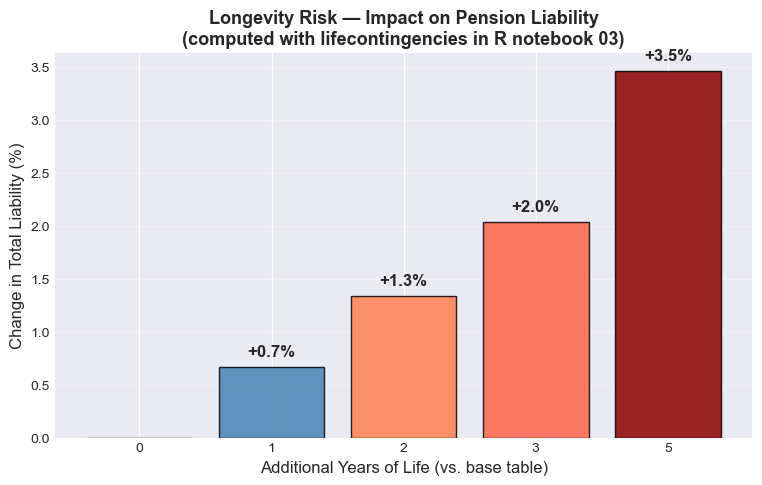

In [12]:
if long_sens is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    clrs_l = ['lightgray'] + ['steelblue','coral','tomato','darkred']
    bars_l = ax.bar(long_sens['shock_years'].astype(str),
                    long_sens['change_pct'],
                    color=clrs_l[:len(long_sens)], alpha=0.85, edgecolor='black')
    for bar, v in zip(bars_l, long_sens['change_pct']):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, v+0.1,
                    f'+{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_xlabel('Additional Years of Life (vs. base table)', fontsize=12)
    ax.set_ylabel('Change in Total Liability (%)', fontsize=12)
    ax.set_title('Longevity Risk — Impact on Pension Liability\n'
                 '(computed with lifecontingencies in R notebook 03)',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.savefig('../results/figures/13_longevity_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Longevity sensitivity data not found. Run R notebook 03 first.')

## 8. Final Summary

In [13]:
print('=' * 65)
print('COMPLETE ALM SUMMARY')
print('=' * 65)
print(f'\nSource: R notebooks (StMoMo + lifecontingencies)')
print(f'\nLiability:')
print(f'  Present Value:      R$ {alm.liab_pv/1e6:>10,.1f}M')
print(f'  Macaulay Duration:  {alm.liab_D_mac:>10.2f} years')
print(f'  Modified Duration:  {alm.liab_D_mod:>10.2f}')
print(f'\nNTN-B Portfolio:')
print(f'  Duration:           {alm.asset_D_mac:>10.2f} years')
print(f'\nDuration Gap:         {alm.duration_gap:>10.2f} years')
msg = ('Well-matched' if abs(alm.duration_gap)<1
       else 'Rate DROP increases deficit' if alm.duration_gap>0
       else 'Rate RISE increases deficit')
print(f'  Assessment: {msg}')
print('=' * 65)

COMPLETE ALM SUMMARY

Source: R notebooks (StMoMo + lifecontingencies)

Liability:
  Present Value:      R$      494.8M
  Macaulay Duration:       18.52 years
  Modified Duration:       17.51

NTN-B Portfolio:
  Duration:                 9.33 years

Duration Gap:               9.19 years
  Assessment: Rate DROP increases deficit
